### Assignment 1 Task 2

In [1]:
import pygame
from pygame.locals import *
import random
import os
import math
import torch as t
import numpy as np
import matplotlib.pyplot as plt

pygame 2.6.1 (SDL 2.28.4, Python 3.10.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


##### Constants

In [2]:
WIDTH = 500
SIZE = (WIDTH, WIDTH)

Swarm_count=150
Cycle_length=50
display=False

RED = (255, 0, 0)
YELLOW = (255, 255, 0)
BLACK = (0, 0, 0)
Background_Color = (0, 0, 0)

#### Generating Swarms

In [3]:
swarms=t.zeros((Swarm_count, 3))
swarms[:,0]=t.randint(1,WIDTH,(Swarm_count,))
swarms[:,1]=t.randint(1,WIDTH,(Swarm_count,))
swarms[:,2]=t.randint(0,Cycle_length,(Swarm_count,))
"""swarms=t.Tensor([[5,1,1],[15,1,10],[5,6,20],[15,6,30],[10,11,40],
                 [305,301,1],[315,301,10],[305,306,20],[315,306,30],[310,311,40]])"""

'swarms=t.Tensor([[5,1,1],[15,1,10],[5,6,20],[15,6,30],[10,11,40],\n                 [305,301,1],[315,301,10],[305,306,20],[315,306,30],[310,311,40]])'

#### Util Functions

In [4]:
def get_swarm_color(swarm):
    if swarm[2] < Cycle_length//2:
        return YELLOW
    else:
        return BLACK
def get_neighbors(swarms,radius=10):
    """neighbors = []
    for other in swarms:
        if other is not swarm:
            distance = t.sqrt((swarm[0] - other[0])**2 + (swarm[1] - other[1])**2)
            if distance < radius:  # neighboring radius
                neighbors.append(other)
    return neighbors"""
    pos = swarms[:, :2]          # shape [50,2]
    diff = pos[:, None, :] - pos[None, :, :]
    dist = t.sqrt((diff ** 2).sum(dim=-1))
    neighbors_mask = dist < radius
    neighbors_mask.fill_diagonal_(False)
    neighbors = [
        t.where(neighbors_mask[i])[0].tolist()
        for i in range(len(swarms))
    ]
    #for i, n in enumerate(neighbors):
    #    print(f"Swarm {i}: neighbors -> {n.tolist()}")
    return neighbors

def get_average_neighbours(swarms,radius):
    neighbours=get_neighbors(swarms,radius)
    sum=0
    for n in neighbours:
        sum+=len(n)
    return sum/ swarms.shape[0]

def synchronize_flashing(swarm,neighbours):
    """ 
        neighbours of the swarm.
    """    
    
    flashing_sum=0
    for neighbour in neighbours:
        flashing_sum+=swarms[neighbour,2]
    if len(neighbours)!=0 and flashing_sum/len(neighbours) < Cycle_length/2:
        swarm[2]= (swarm[2] + 1) % Cycle_length
def shuffle_flashes():
    swarms[:,2]=t.randint(1,Cycle_length,(Swarm_count,))

def count_flashing_swarms(swarms):
    mask = swarms[:, 2] <= Cycle_length // 2
    return mask.sum().item()

def plot_flashing_swarms(number_of_flashing_swarms,title,xlabel,ylabel):
    plt.figure(figsize=(8, 3))
    plt.plot(number_of_flashing_swarms, linewidth=0.8, alpha=0.8)  # thin line + slight transparency
    plt.ylim(0,150)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### a)

In [5]:
print(f"Average number of neighbors per firefly = {get_average_neighbours(swarms,WIDTH*0.05)}, vicinity distances = {0.05}")
print(f"Average number of neighbors per firefly = {get_average_neighbours(swarms,WIDTH*0.1)}, vicinity distances = {0.1}")
print(f"Average number of neighbors per firefly = {get_average_neighbours(swarms,WIDTH*1.4)}, vicinity distances = {1.4}")

Average number of neighbors per firefly = 1.12, vicinity distances = 0.05
Average number of neighbors per firefly = 4.466666666666667, vicinity distances = 0.1
Average number of neighbors per firefly = 149.0, vicinity distances = 1.4


In [6]:
print(f"Average number of neighbors per firefly = {get_average_neighbours(swarms,WIDTH*0.9)}, vicinity distances = {1.4}")

Average number of neighbors per firefly = 140.09333333333333, vicinity distances = 1.4


### Simulation

In [7]:
def start_simulation(neighbouring_radius):
    import pygame

    pygame.init()
    pygame.display.set_caption("Swarm Simulation")
    FPS=25
    frame_counter=0
    Background_Color = (0, 0, 0)   # black
    Point_Color = (255, 255, 255)  # white

    running = True
    clock = pygame.time.Clock()

    screen = pygame.display.set_mode(SIZE)
    pygame.display.set_caption("Swarm Simulation")

    #neighbours=get_neighbors(swarms,radius=WIDTH*0.05)
    #neighbours=get_neighbors(swarms,radius=WIDTH*0.1)
    #neighbours=get_neighbors(swarms,radius=WIDTH*1.4)
    neighbours=get_neighbors(swarms,radius=WIDTH*neighbouring_radius)
    number_of_flashing_swarms=[count_flashing_swarms(swarms)]
    while running:
        frame_counter+=1
        #clock.tick(FPS)
        
        if frame_counter >= 5000:
            break
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
        screen.fill(Background_Color)
        
        # draw points
        for i,swarm in enumerate(swarms):
            pygame.draw.circle(screen, get_swarm_color(swarm), (swarm[0].item(), swarm[1].item()), 2)
            if swarm[2] % Cycle_length == 0:
                synchronize_flashing(swarm,neighbours[i])
        swarms[:,2] = (swarms[:,2] + 1) % Cycle_length

        number_of_flashing_swarms.append(count_flashing_swarms(swarms))
        # update display
        pygame.display.flip()
    pygame.quit()
    return number_of_flashing_swarms


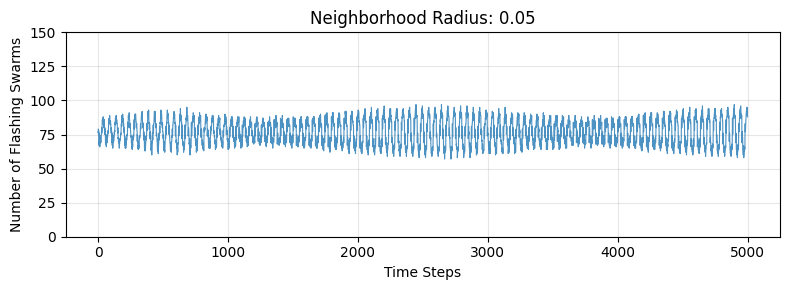

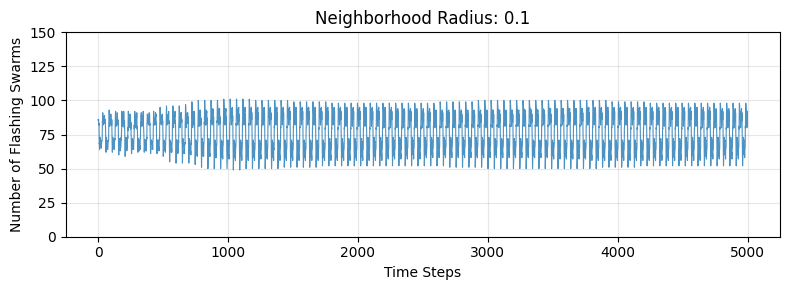

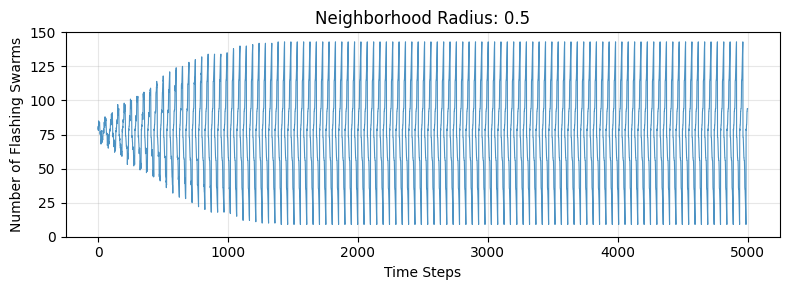

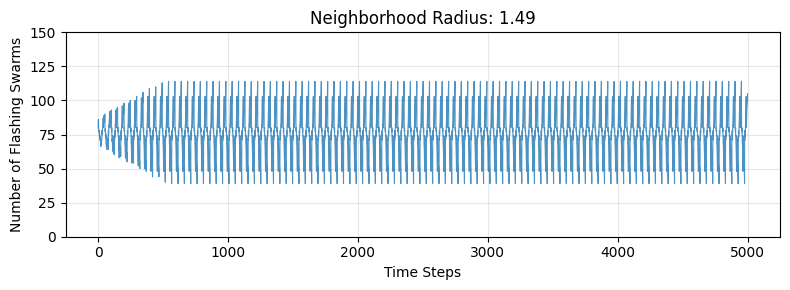

In [8]:
shuffle_flashes()
number_of_flashing_swarms=start_simulation(0.05)
plot_flashing_swarms(number_of_flashing_swarms, title='Neighborhood Radius: 0.05', xlabel='Time Steps', ylabel='Number of Flashing Swarms')
shuffle_flashes()
number_of_flashing_swarms=start_simulation(0.1)
plot_flashing_swarms(number_of_flashing_swarms, title='Neighborhood Radius: 0.1', xlabel='Time Steps', ylabel='Number of Flashing Swarms')
shuffle_flashes()
number_of_flashing_swarms=start_simulation(0.5)
plot_flashing_swarms(number_of_flashing_swarms, title='Neighborhood Radius: 0.5', xlabel='Time Steps', ylabel='Number of Flashing Swarms')
shuffle_flashes()
number_of_flashing_swarms=start_simulation(1.49)
plot_flashing_swarms(number_of_flashing_swarms, title='Neighborhood Radius: 1.49', xlabel='Time Steps', ylabel='Number of Flashing Swarms')

